> title : 데이터 탐색 <br>
> author : jacobgreen <br>

# 🔈 대회 소개
1. 대회명 : 건설공사 사고 예방 및 대응책 생성 <한솔데코 시즌3 AI 경진대회> <br>
2. 소개 : 시즌3 경진대회에서는 건설공사 사고 상황 데이터를 기반으로 사고 원인을 분석하고, 재발방지 대책 및 향후 조치 계획을 자동으로 생성하는 AI 모델을 개발하는 것이 목표입니다. 참가자들은 실제 사고 데이터를 학습하여 건설 현장의 사고 대응 역량을 향상시키고, 효과적인 안전관리 프로세스를 구축하는 AI 기술을 연구하게 됩니다. <br>
3. URL : https://dacon.io/competitions/official/236455/codeshare <br>
<img src="https://dacon.s3.ap-northeast-2.amazonaws.com/competition/236455/header_background.jpeg" style="width:100%; height:auto;">

In [1]:
! apt-get update -qq
! apt-get install fonts-nanum -qq > /dev/null

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import re
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 1. 설치된 나눔고딕 폰트 경로 확인
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# 2. Matplotlib 기본 폰트로 설정
fm.fontManager.addfont(font_path)  # 폰트 추가
mpl.rc("font", family="NanumGothic")  # 폰트 설정

# 3. 한글 폰트 캐시 삭제 및 다시 로드
mpl.font_manager._load_fontmanager()

pd.set_option("display.max_columns", None)  # 모든 컬럼 출력
pd.set_option("display.max_colwidth", None)  # 컬럼 내용 생략 없음

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [14]:
def check_duplicate_rows(train: pd.DataFrame, test: pd.DataFrame, subset: list = None):
    """
    train 데이터의 샘플이 test 데이터에도 존재하는지 확인하는 함수.
    
    Parameters:
    train (pd.DataFrame): 학습 데이터
    test (pd.DataFrame): 테스트 데이터
    subset (list, optional): 특정 컬럼 리스트. 지정하면 해당 컬럼들만 비교
    
    Returns:
    pd.DataFrame: train과 test에서 중복된 샘플
    """
    if subset:
        duplicates = train.merge(test, on=subset, how='inner')
    else:
        duplicates = train.merge(test, how='inner')

    print('# duplicates:',len(duplicates))
    
    return duplicates

In [2]:
train = pd.read_csv('/kaggle/input/project7/train.csv', encoding = 'utf-8-sig')
test = pd.read_csv('/kaggle/input/project7/test.csv', encoding = 'utf-8-sig')

## (🔨) 데이터 전처리

In [3]:
# 데이터 전처리
# 공사종류, 공종, 사고객체 -> 대분류, 중분류로 파생 
train['공사종류(대분류)'] = train['공사종류'].str.split(' / ').str[0]
train['공사종류(중분류)'] = train['공사종류'].str.split(' / ').str[1]
train['공종(대분류)'] = train['공종'].str.split(' > ').str[0]
train['공종(중분류)'] = train['공종'].str.split(' > ').str[1]
train['사고객체(대분류)'] = train['사고객체'].str.split(' > ').str[0]
train['사고객체(중분류)'] = train['사고객체'].str.split(' > ').str[1]

test['공사종류(대분류)'] = test['공사종류'].str.split(' / ').str[0]
test['공사종류(중분류)'] = test['공사종류'].str.split(' / ').str[1]
test['공종(대분류)'] = test['공종'].str.split(' > ').str[0]
test['공종(중분류)'] = test['공종'].str.split(' > ').str[1]
test['사고객체(대분류)'] = test['사고객체'].str.split(' > ').str[0]
test['사고객체(중분류)'] = test['사고객체'].str.split(' > ').str[1]

In [4]:
# 컬럼명 변경
train = train.rename(columns={'사고인지 시간':'사고인지시간'})
test = test.rename(columns={'사고인지 시간':'사고인지시간'})
train = train.rename(columns={'재발방지대책 및 향후조치계획':'재발방지대책'})
test['재발방지대책'] = None

# 컬럼 순서 정렬 
feats = ['ID',
 '발생일시',
 '사고인지시간',
 '날씨',
 '기온',
 '습도',
 '공사종류',
 '연면적',
 '층 정보',
 '인적사고',
 '물적사고',
 '공종',
 '사고객체',
 '작업프로세스',
 '장소',
 '부위',
 '공사종류(대분류)',
 '공사종류(중분류)',
 '공종(대분류)',
 '공종(중분류)',
 '사고객체(대분류)',
 '사고객체(중분류)',
 '사고원인',
 '재발방지대책'
]

train = train[feats]
test = test[feats]

In [5]:
data = pd.concat([train,test]).reset_index(drop=True)
data['데이터유형'] = data['ID'].str.replace(r"\d+", "", regex=True)
data['발생일자'] = data['발생일시'].str[:10]
data['발생월'] = data['발생일시'].str[:7]
data.head(1)

,ID,발생일시,사고인지시간,날씨,기온,습도,공사종류,연면적,층 정보,인적사고,물적사고,공종,사고객체,작업프로세스,장소,부위,공사종류(대분류),공사종류(중분류),공종(대분류),공종(중분류),사고객체(대분류),사고객체(중분류),사고원인,재발방지대책,데이터유형,발생일자,발생월
0,TRAIN_00000,2023-12-31 오후 12:44,정규작업 -,맑음,1℃,30%,건축 / 건축물 / 근린생활시설,"4,892.77㎡","지상 14층, 지하 3층",떨어짐(5미터 이상 ~ 10미터 미만),없음,건축 > 철근콘크리트공사,건설자재 > 철근,설치작업,근린생활시설 / 내부,철근 / 고소,건축,건축물,건축,철근콘크리트공사,건설자재,철근,"고소작업 중 추락 위험이 있음에도 불구하고, 안전난간대, 안전고리 착용 등 안전장치가 미흡하였음.",고소작업 시 추락 위험이 있는 부위에 안전장비 설치.,TRAIN_,2023-12-31,2023-12


In [9]:
"""
사고원인 유형별 재분류 

#부주의 #넘어짐 #미끄러짐 #작업미숙
"""

data['사고원인유형_알수없음'] = np.where(data['사고원인'].isin(['.','-','미상','원인미상','작업자','알수없음']),'알수없음','')
data['사고원인유형_알수없음'] = np.where(data['사고원인'].str.contains('알수없음'),'알수없음',data['사고원인유형_알수없음'])
data['사고원인유형_조사중'] = np.where(data['사고원인'].str.contains('조사|파악 중'),'조사중','')
data['사고원인유형_기타'] = np.where(data['사고원인'].str.contains('기타|해당없음'),'기타','')
data['사고원인유형_작업자부주의'] = np.where(data['사고원인'].str.contains('부주의|부주위'),'작업자부주의','')
data['사고원인유형_과실'] = np.where(data['사고원인'].str.contains('과실|실수'),'작업자부주의','')
data['사고원인유형_불안전한행동'] = np.where(data['사고원인'].str.contains('불안전한 행동|불안전한 작업자세|불안전한|불완전한|무리한|무리하게|부적절한|부적정'),'작업자부주의','')
data['사고원인유형_넘어짐'] = np.where(data['사고원인'].str.contains('넘어짐|발걸림'),'넘어짐','')
data['사고원인유형_미끄러짐'] = np.where(data['사고원인'].str.contains('미끄러'),'미끄러짐','')
data['사고원인유형_추락낙상'] = np.where(data['사고원인'].str.contains('추락|낙상'),'추락','')
data['사고원인유형_발헛디딤'] = np.where(data['사고원인'].str.contains('헛디딤|헛딛음|디뎌'),'발헛디딤','')
data['사고원인유형_작업미숙'] = np.where(data['사고원인'].str.contains('작업미숙|미숙|미흡'),'작업미숙','')
data['사고원인유형_작업방법불량'] = np.where(data['사고원인'].str.contains('작업방법 불량'),'작업방법불량','')
data['사고원인유형_근골격계질환'] = np.where(data['사고원인'].str.contains('근골격계'),'근골격계','')
data['사고원인유형_질병'] = np.where(data['사고원인'].str.contains('질병|심장마비'),'질병','')
data['사고원인유형_안전불량'] = np.where(data['사고원인'].str.contains('안전|안정|미착용|미사용|미실시|미준수|미확보|미확인|미 실시|미 확인|미설치|비규격화|전방주의 부족|확인 부족'),'안전불량','')
data['사고원인유형_오작동'] = np.where(data['사고원인'].str.contains('오작동'),'오작동','')
data['사고원인유형_작업중이동'] = np.where(data['사고원인'].str.contains('이동'),'작업중이동','')
data['사고원인유형_작업태도불량'] = np.where(data['사고원인'].str.contains('불량|주의태만|관리소홀'),'작업태도불량','')
data['사고원인유형_신호불일치'] = np.where(data['사고원인'].str.contains('불일치'),'신호불일치','')
data['사고원인유형_정리정돈'] = np.where(data['사고원인'].str.contains('정리'),'정리','')
data['사고원인유형_타격'] = np.where(data['사고원인'].str.contains('타격|타박'),'타격','')
data['사고원인유형_끼임'] = np.where(data['사고원인'].str.contains('끼임'),'끼임','')
data['사고원인유형_부딪힘'] = np.where(data['사고원인'].str.contains('부딪힘'),'부딪힘','')
data['사고원인유형_그라인더'] = np.where(data['사고원인'].str.contains('그라인더|그라인드'),'그라인더','')
data['사고원인유형_화재'] = np.where(data['사고원인'].str.contains('화재'),'화재','')
data['사고원인유형_바닥'] = np.where(data['사고원인'].str.contains('바닥'),'바닥','')
data['사고원인유형_중심잃음'] = np.where(data['사고원인'].str.contains('중심을 잃음'),'중심잃음','')
data['사고원인유형_교통사고'] = np.where(data['사고원인'].str.contains('교통'),'교통','')
data['사고원인유형_협착'] = np.where(data['사고원인'].str.contains('협착'),'협착','')
data['사고원인유형_골절'] = np.where(data['사고원인'].str.contains('골절'),'골절','')
data['사고원인유형_절단'] = np.where(data['사고원인'].str.contains('절단'),'절단','')
data['사고원인유형_손가락'] = np.where(data['사고원인'].str.contains('손가락'),'손가락','')
data['사고원인유형_발목'] = np.where(data['사고원인'].str.contains('발목'),'발목','')
data['사고원인유형_발등'] = np.where(data['사고원인'].str.contains('발등'),'발등','')
data['사고원인유형_허리'] = np.where(data['사고원인'].str.contains('허리'),'허리','')
data['사고원인유형_피로'] = np.where(data['사고원인'].str.contains('피로|쓰러짐|무리'),'피로','')

feats = [i for i in data.columns if '사고원인유형_' in i]
data['사고원인유형'] = data[feats].apply(lambda x:' '.join(sorted(x)).strip().replace(' ','|'),axis=1)
print('# 미분류:',np.round((data['사고원인유형']=='').sum()/len(data)*100,2),'%')
data['사고원인유형'] = np.where(data['사고원인유형']=='','미분류',data['사고원인유형'])

# 미분류: 18.42 %


# 📂 데이터탐색 목차
- (🔨) 데이터 전처리
- (✔️) 결측치 확인
- (✔️) train, test 발생일시 시간순서 
- (✔️) train, test 카테고리 유형 비교
- (✔️) train, test 사고 시계열 분석 
- (✔️) 사고가 많이 발생하는 유형
- (✔️) 사고원인 유형별 재분류
- (✔️) 사고원인별 평균 재발방지대책 길이 (최대,최소,평균)
- train event가 test에 있는지 확인 (information leakage)
- 재발방지대책 유형화 
- 사고유형 vs 재발방지대책
- 사고원인 : (비정형) 수기 작성내용
- 재발방지대책 : (비정형) 수기 작성내용
  
[❔가설]
- 시간이 지나면서 사고원인도 변경되었을 것이다.

[💡발견]
- test에 균등 random sampling을 통해 생성된 데이터 

In [10]:
feats = [
     '공사종류'
    ,'인적사고'
    ,'물적사고'
    ,'공종'
    ,'사고객체'
    ,'작업프로세스'
    ,'장소'
    ,'부위'
    ,'사고원인유형'
]
print('# 중복건:',len(data) - len(data[feats].drop_duplicates()))
print('# test:',len(test))
data[feats].head()

# 중복건: 175
# test: 964


,공사종류,인적사고,물적사고,공종,사고객체,작업프로세스,장소,부위,사고원인유형
0,건축 / 건축물 / 근린생활시설,떨어짐(5미터 이상 ~ 10미터 미만),없음,건축 > 철근콘크리트공사,건설자재 > 철근,설치작업,근린생활시설 / 내부,철근 / 고소,안전불량|작업미숙|추락
1,토목 / 터널 / 철도터널,끼임,없음,토목 > 터널공사,건설자재 > 볼트,운반작업,철도터널 / 내부,볼트 / 바닥,작업자부주의
2,건축 / 건축물 / 업무시설,넘어짐(미끄러짐),없음,건축 > 철근콘크리트공사,기타 > 기타,형틀 및 목공,업무시설 / 내부,기타 / 바닥,미끄러짐|작업중이동
3,토목 / 하천 / 기타,기타,전도,토목 > 하천공사,부재 > 교각 기초,조립작업,기타 / 동산교 신축구간,교각 기초 / 바닥,미분류
4,건축 / 건축물 / 공동주택,넘어짐(미끄러짐),없음,건축 > 해체 및 철거공사,기타 > 건설폐기물,해체작업,공동주택 / 내부,건설폐기물 / 바닥,작업자부주의


In [11]:
data['인적사고'].nunique()

23

In [15]:
feats = [
     '공사종류'
    ,'인적사고'
    ,'물적사고'
    ,'공종'
    ,'사고객체'
    ,'작업프로세스'
    ,'장소'
    ,'부위'
    ,'사고원인유형'
]

duplicates = check_duplicate_rows(
      train = data.loc[data['데이터유형']=='TRAIN_',:]
    , test = data.loc[data['데이터유형']=='TEST_',:]
    , subset = feats
)

# duplicates: 7


In [10]:
data.groupby(['데이터유형'])[feats].value_counts().reset_index()

,데이터유형,공사종류,인적사고,물적사고,공종,사고객체,작업프로세스,장소,부위,사고원인유형,count
0,TEST_,건축 / 건축물 / 공동주택,분류불능,없음,건축 > 건축 토공사,기타 > 기타,기타,공동주택 / 내부,기타 / 바닥,미분류,2
1,TEST_,건축 / 건축물 / 공동주택,교통사고,없음,기타 > 기타,기타 > 차량,정리작업,공동주택 / 외부,차량 / 옆,작업자부주의,1
2,TEST_,건축 / 건축물 / 공동주택,기타,없음,건축 > 건축 토공사,기타 > 기타,운반작업,공동주택 / 내부,기타 / 바닥,작업태도불량,1
3,TEST_,건축 / 건축물 / 공동주택,기타,없음,건축 > 건축물 부대공사,가시설 > 기타 가시설,해체작업,공동주택 / 외부,기타 가시설 / 바닥,미분류,1
4,TEST_,건축 / 건축물 / 공동주택,기타,없음,건축 > 목공사,건설공구 > 공구류,설치작업,공동주택 / 내부,공구류 / 상부(위),골절|손가락|절단,1
...,...,...,...,...,...,...,...,...,...,...,...
22301,TRAIN_,토목 / 항만 / 호안,"절단, 베임",없음,토목 > 항만공사,건설공구 > 공구류,절단작업,호안 / 외부,공구류 / 바닥,작업미숙,1
22302,TRAIN_,토목 / 항만 / 호안,"절단, 베임",없음,토목 > 항만공사,건설공구 > 공구류,절단작업,호안 / 외부,공구류 / 앞,그라인더|손가락|절단,1
22303,TRAIN_,토목 / 항만 / 호안,"절단, 베임",없음,토목 > 항만공사,건설공구 > 공구류,절단작업,호안 / 인접주변,공구류 / 앞,손가락|안전불량|절단,1
22304,TRAIN_,토목 / 항만 / 호안,질병,없음,토목 > 항만공사,질병 > 질병,해체작업,호안 / 외부,질병 / 하부(아래),질병,1


## (✔️) 사고원인별 평균 재발방지대책 길이 (최대,최소,평균)

<Axes: xlabel='재발방지대책'>

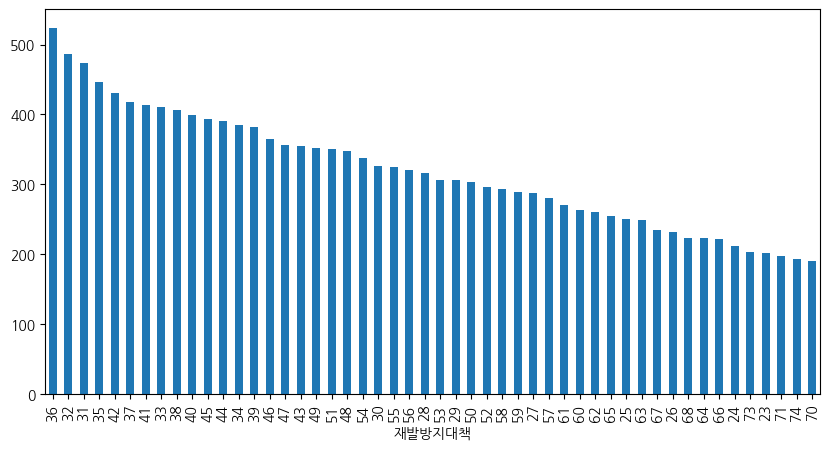

In [324]:
data.loc[data['데이터유형']=='TRAIN_','재발방지대책'].fillna('').apply(len).value_counts().head(50).plot.bar(figsize=(10,5))

In [356]:
# 사고원인별 평균 재발방지대책 길이 (최대,최소,평균)
print('# 전체평균길이:',data.loc[data['데이터유형']=='TRAIN_','재발방지대책'].str.len().mean())
data.loc[data['데이터유형']=='TRAIN_',:].groupby(['사고원인유형']).apply(lambda x:pd.Series({
     '건수' : len(x)
    ,'평균길이' : np.round(x['재발방지대책'].str.len().mean(),2)
    ,'중앙값' : np.round(x['재발방지대책'].str.len().median(),2)
    ,'최대길이' : np.round(x['재발방지대책'].str.len().max(),2)
    ,'최소길이' : np.round(x['재발방지대책'].str.len().min(),2)
    ,'샘플' : x['재발방지대책'][0:5].tolist()[0]
}),include_groups=False).reset_index().sort_values(['건수'],ascending=False).head(20)

# 전체평균길이: 60.18768679019725


,사고원인유형,건수,평균길이,중앙값,최대길이,최소길이,샘플
783,미분류,4318,59.76,51.0,329,7,"위험성 평가 및 교육을 통해 작업장 내 위험요인과 안전수칙을 근로자에게 전파하고, 근로자 안전교육을 강화하며, 본 사고와 관련된 유사 피해 발생 방지를 위한 안전교육을 실시할 계획."
1363,작업자부주의,1805,49.81,42.0,215,7,재발 방지 대책 마련과 안전교육 실시.
1189,안전불량,1101,65.87,58.0,274,11,호스 및 장비 고장 시 작업방법 및 절차 수립과 TBM 및 정기교육 시 적절한 개인보호구 착용 및 관련 사고사례 교육.
1408,작업중이동,663,62.02,54.0,299,10,틀비계 해치발판 및 내부 승강용 사다리 설치와 조치계획 실시 확인을 통한 재발 방지 대책 마련.
1326,작업미숙,645,66.46,59.0,261,8,TBM을 통한 재해사례 전파 및 지속적인 교육 실시와 안전교육 지도를 포함한 향후 조치 계획.
607,미끄러짐,633,53.40,46.0,266,7,작업자 재교육 실시와 병원 응급조치 이후의 휴식 중 재발 방지 대책 마련.
1238,안전불량|작업자부주의,517,67.48,60.0,229,11,"공사 중지와 위험성 평가 재검토 및 재수립, 안전교육 시행, 현장 내 안전시설물 재점검 및 보강, 안전 보호 장비 착용 후 작업 시행, 위험성 평가 반영한 작업계획 수립 및 안전교육 실시, 작업방법에 대한 상시 관리감독 및 작업자 맞춤 안전교육 실시."
476,넘어짐,508,51.74,44.0,218,8,작업자 불안전한 행동에 대한 특별교육 실시와 사고 사례 전파를 통한 동일 사고 재발 방지.
1472,추락,504,58.37,52.0,251,9,"건설기계 주기적 비파괴 검사 및 연결핀 점검, 근로자 안전벨트 착용 교육 관리와 상하 동시작업 통제의 위험성 평가 반영."
784,바닥,321,57.17,48.0,218,7,"작업구간 실족방지망 설치, 안전보호구 착용 관련 안전교육 실시 및 해당 작업 관련 위험성 교육과 작업 전 충분한 작업 준비, 관리 감독 철저."


## (✔️) 사고원인 유형별 재분류  

# 미분류: 18.42 %


<Axes: xlabel='사고원인유형'>

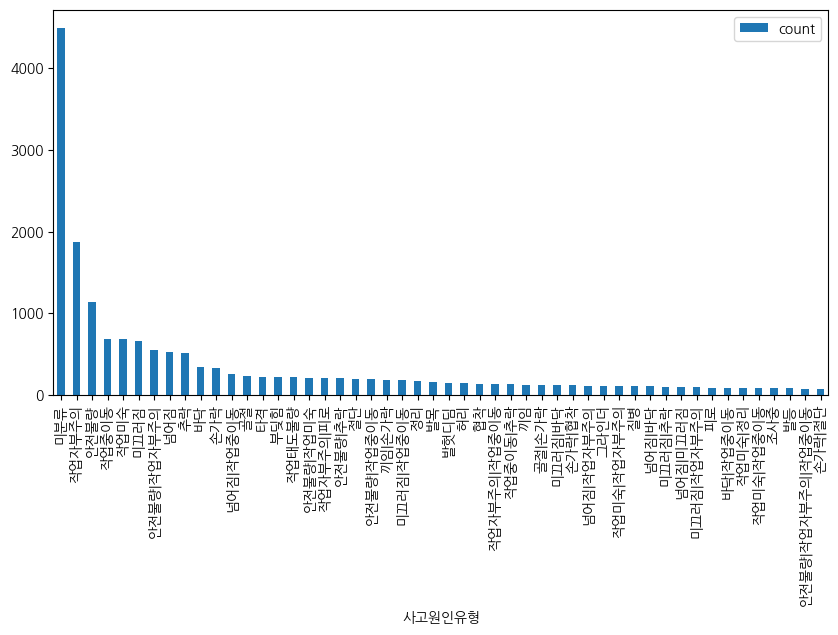

In [310]:
data['사고원인유형'].value_counts().reset_index().head(50).set_index(['사고원인유형']).plot.bar(figsize=(10,5))

In [288]:
#  [사고원인]    --->  [재발방지대책]
# 작업자부주의   --->  동일한 사고가 발생하지 않도록 안전교육 실시.
data.loc[data['사고원인유형']=='','사고원인'].value_counts().reset_index().head(20) # ['재발방지대책'].tolist()

,사고원인,count
0,작업자 요양급여 결정,2
1,비계 전도,2
2,건물 2층에서 휴식 후 작업 재개를 위해 일어나는 중 어지러움을 호소하며 떨어짐(같이 작업하는 동료 진술),2
3,단독작업,2
4,신호수 가 덤프트럭과 서로 인지를 못하여 사고발생,2
5,돌풍,2
6,작업 중 실족,2
7,4단 사다리에 올라가다 3단(높이80cm) 위치에서 천정에 있는 배관을 잡고 올라서다가 배관이 끊어져서 중심을 잃고뒤로 떨어진 사고,2
8,순차적으로 해체하지 않음,2
9,소음사업장에서 근무,2


## (✔️) 결측치 확인

In [184]:
# 결측치 확인
data.groupby(['데이터유형']).apply(lambda x: np.round(x.isna().sum()/len(x)*100,2),include_groups=False).T.applymap(str).replace('0.0','')

<ipython-input-184-41ce629df503>:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data.groupby(['데이터유형']).apply(lambda x: np.round(x.isna().sum()/len(x)*100,2),include_groups=False).T.applymap(str).replace('0.0','')


데이터유형,TEST_,TRAIN_
ID,,
발생일시,,
사고인지시간,,
날씨,,
기온,,
습도,,
공사종류,,
연면적,,
층 정보,,
인적사고,,0.14


## (✔️) train, test 발생일시 시간순서 

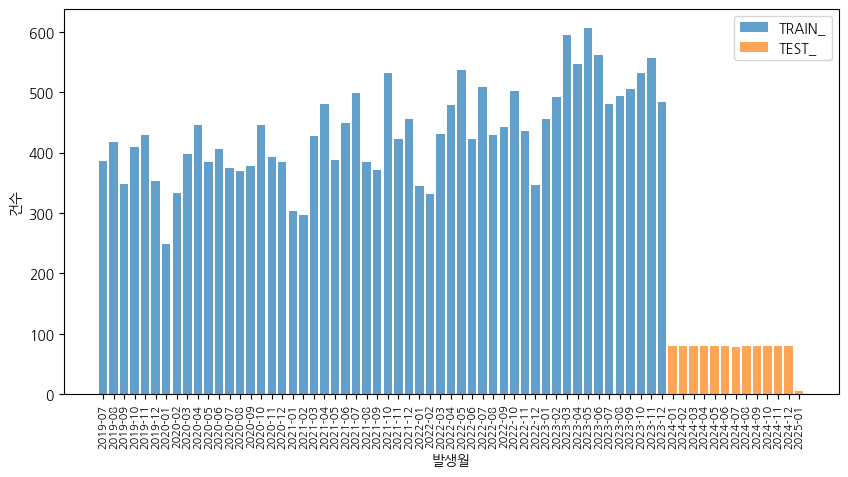

In [74]:
a1 = data.groupby(["데이터유형","발생월"]).size().reset_index(name='건수')

# a1["발생월"] = pd.to_datetime(a1["발생월"])  # 날짜 형식 변환

# 그래프 생성
fig, ax = plt.subplots(figsize=(10, 5))

# train과 test를 그룹화하여 개별 출력
for category, group in sorted(a1.groupby("데이터유형"),reverse=True):
    ax.bar(group["발생월"], group["건수"], label=category, alpha=0.7)

ax.set_xlabel("발생월")
ax.set_ylabel("건수")
ax.legend()

plt.xticks(rotation=90,size=8);

📌 특징
- train 데이터는 2019년 7월 ~ 2023년 12월
- test 데이터는 2024년 1월 ~ 2025년 1월 

💡 특이점
- train 1,2월에 사고건수 감소
- test 사고건수 균등 (랜덤 샘플링 결과로 보임)

## (✔️) train, test 사고 시계열 분석 

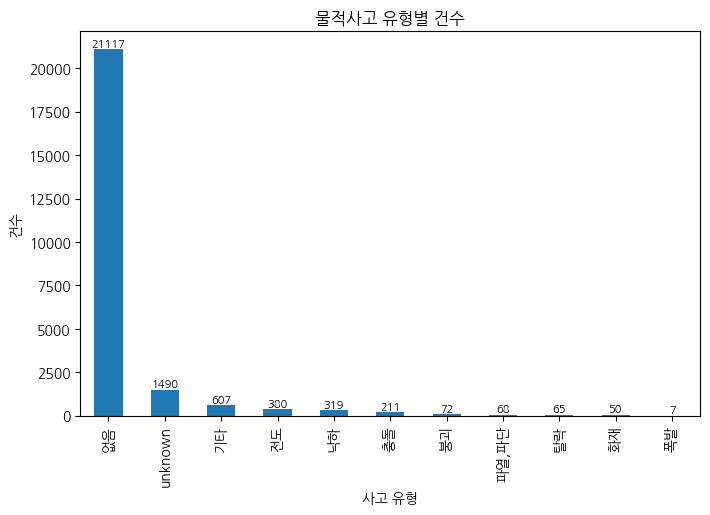

In [40]:
# NaN 값 대체 및 데이터 개수 계산
accident_counts = data["물적사고"].fillna("unknown").value_counts().reset_index()
accident_counts.columns = ["사고 유형", "건수"]

# 막대 그래프 생성
ax = accident_counts.plot.bar(x="사고 유형", y="건수", legend=False, figsize=(8, 5))

# 각 바(bar) 위에 레이블 추가
for i, v in enumerate(accident_counts["건수"]):
    ax.text(i, v + 1, str(v), ha="center", va="bottom", fontsize=8, fontweight="bold")

# 라벨 및 타이틀 설정
plt.xlabel("사고 유형")
plt.ylabel("건수")
plt.title("물적사고 유형별 건수")
plt.xticks(rotation=90)  # X축 라벨 회전

plt.show()

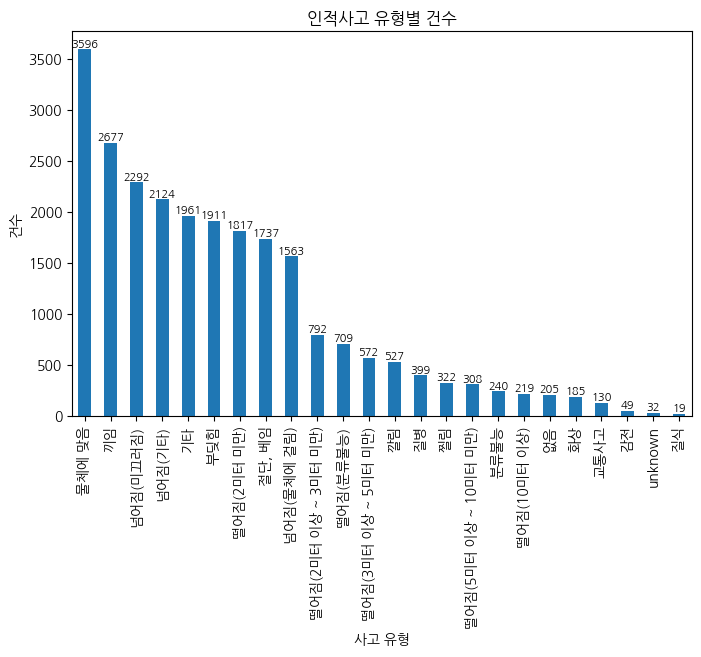

In [39]:
# NaN 값 대체 및 데이터 개수 계산
accident_counts = data["인적사고"].fillna("unknown").value_counts().reset_index()
accident_counts.columns = ["사고 유형", "건수"]

# 막대 그래프 생성
ax = accident_counts.plot.bar(x="사고 유형", y="건수", legend=False, figsize=(8, 5))

# 각 바(bar) 위에 레이블 추가
for i, v in enumerate(accident_counts["건수"]):
    ax.text(i, v + 1, str(v), ha="center", va="bottom", fontsize=8, fontweight="bold")

# 라벨 및 타이틀 설정
plt.xlabel("사고 유형")
plt.ylabel("건수")
plt.title("인적사고 유형별 건수")
plt.xticks(rotation=90)  # X축 라벨 회전

plt.show()

In [122]:
def make_plot1(사고유형):

    # 날짜 데이터 변환
    # data["발생월"] = pd.to_datetime(data["발생월"])
    
    # 데이터 그룹화 (a1: 전체 사고 건수)
    a1 = data.groupby(["데이터유형", "발생월"]).size().reset_index(name="건수")
    
    # 데이터 그룹화 (a2: 특정 사고 유형 '물체에 맞음' 건수)
    a2 = data.groupby(["데이터유형", "발생월"]).apply(lambda x: (x["인적사고"] == 사고유형).sum(),
                                                     include_groups=False).reset_index(name=사고유형+'건수')
    
    # 발생월 기준 정렬
    a1 = a1.sort_values(by="발생월")
    a2 = a2.sort_values(by="발생월")
    
    # 그래프 생성
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # 막대 그래프 (a1: 전체 사고 건수)
    for category, group in sorted(a1.groupby("데이터유형"), reverse=True):
        ax1.bar(group["발생월"], group["건수"], label=f"{category}사고건수", alpha=0.7)
    
    ax1.set_xlabel("발생월")
    ax1.set_ylabel("건수")
    ax1.set_ylim(0, max(a1["건수"]) * 1.2) 
    
    
    # X축 포맷 및 글꼴 크기 조정
    plt.xticks(rotation=90, size=8);
    
    # 선 그래프 (a2: 물체에 맞음 사고 건수) - Y축 공유
    ax2 = ax1.twinx()
    for category, group in sorted(a2.groupby("데이터유형"), reverse=True):
        ax2.plot(group["발생월"], group[사고유형+'건수'], label=f"{category}{사고유형+'건수'}",
                 marker="o", linestyle="-", linewidth=1.5)

        # 각 데이터 포인트에 레이블 추가
        for i, (x, y) in enumerate(zip(group["발생월"], group[사고유형+'건수'])):
            ax2.text(x, y, str(y), fontsize=8, ha="right", va="bottom", color="black")
        
    ax2.set_ylabel(사고유형+'건수') 
    
    ax1.legend(loc="upper left", bbox_to_anchor=(1.05, 1))
    ax2.legend(loc="upper left", bbox_to_anchor=(1.05, 0.8))
    
    plt.title(사고유형)
    plt.show()

물체에 맞음


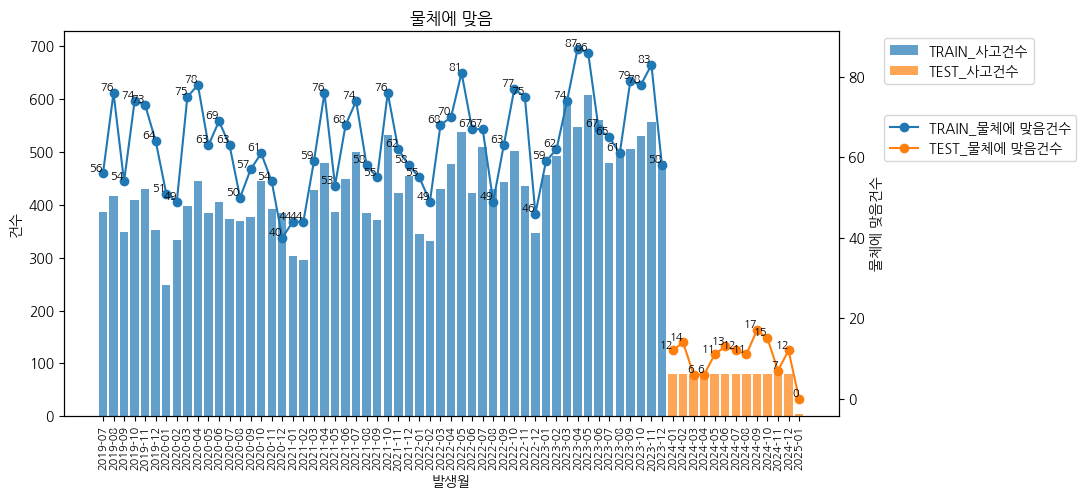

끼임


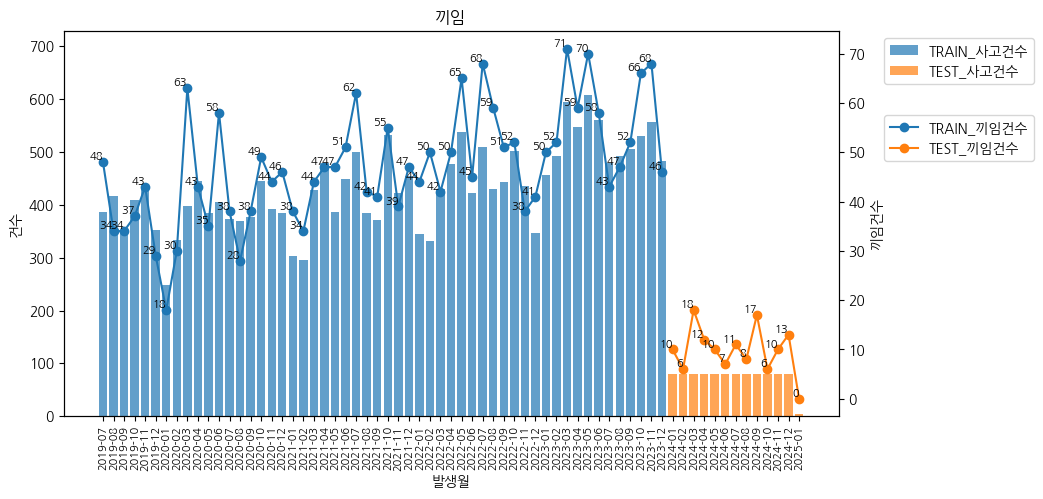

넘어짐(미끄러짐)


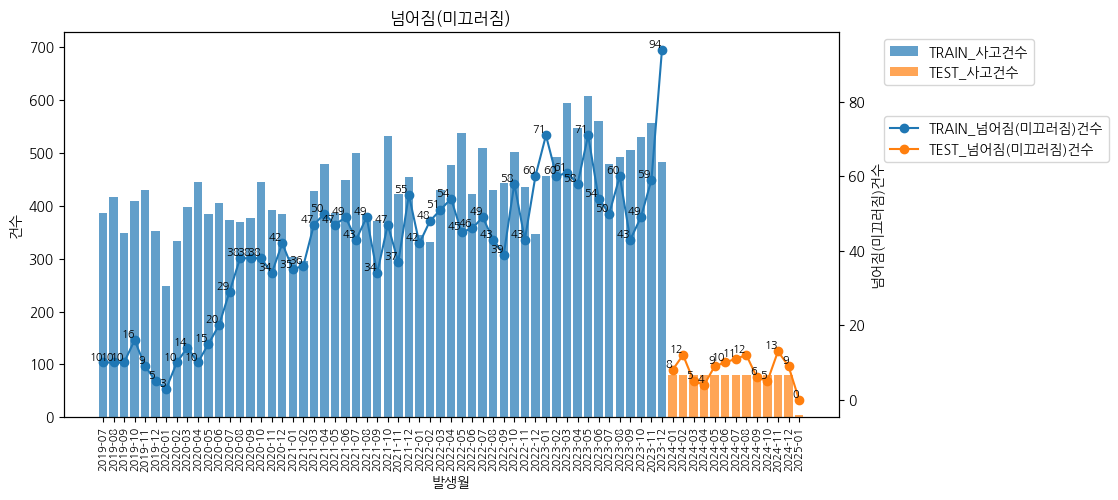

넘어짐(기타)


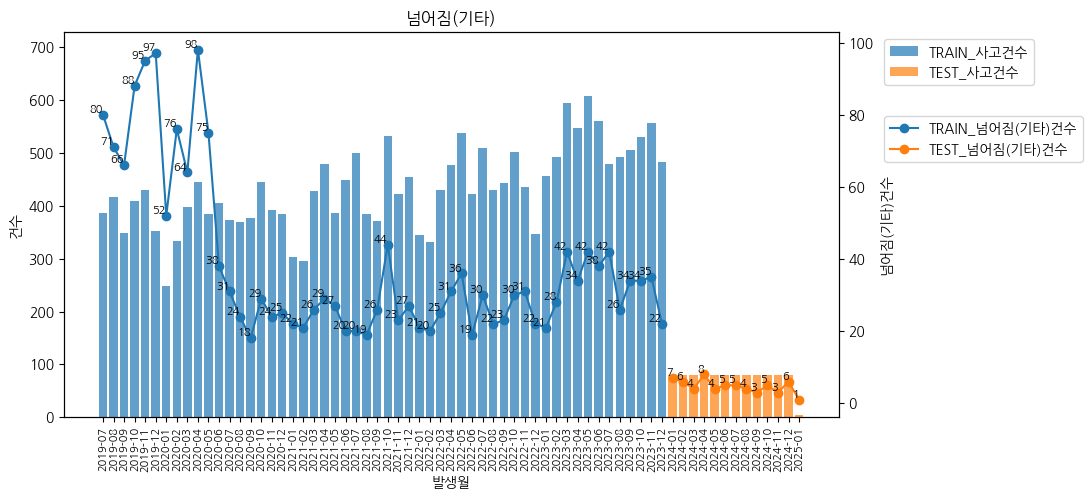

기타


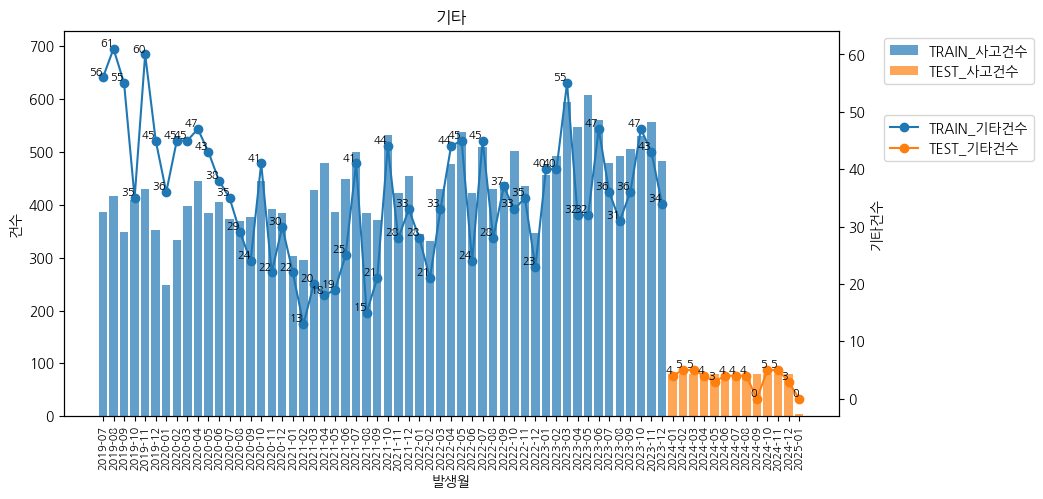

부딪힘


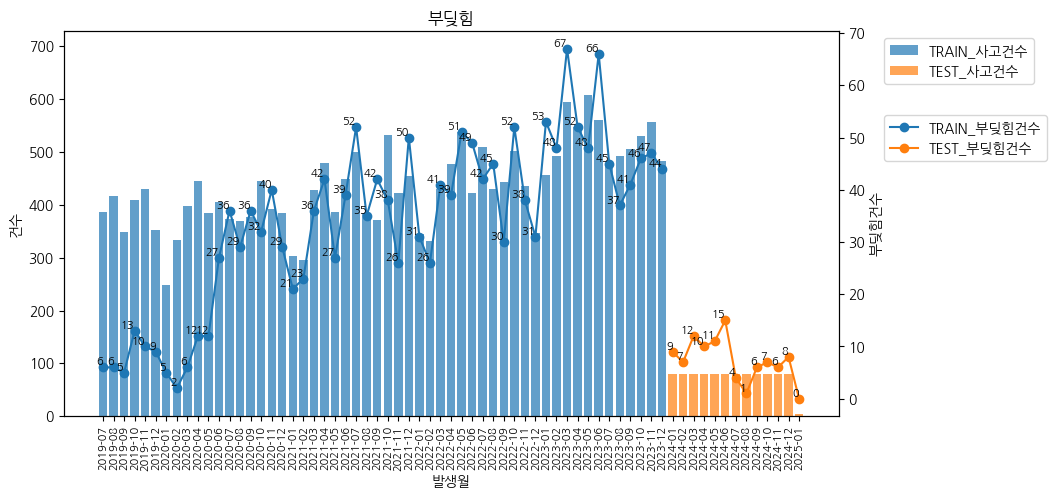

떨어짐(2미터 미만)


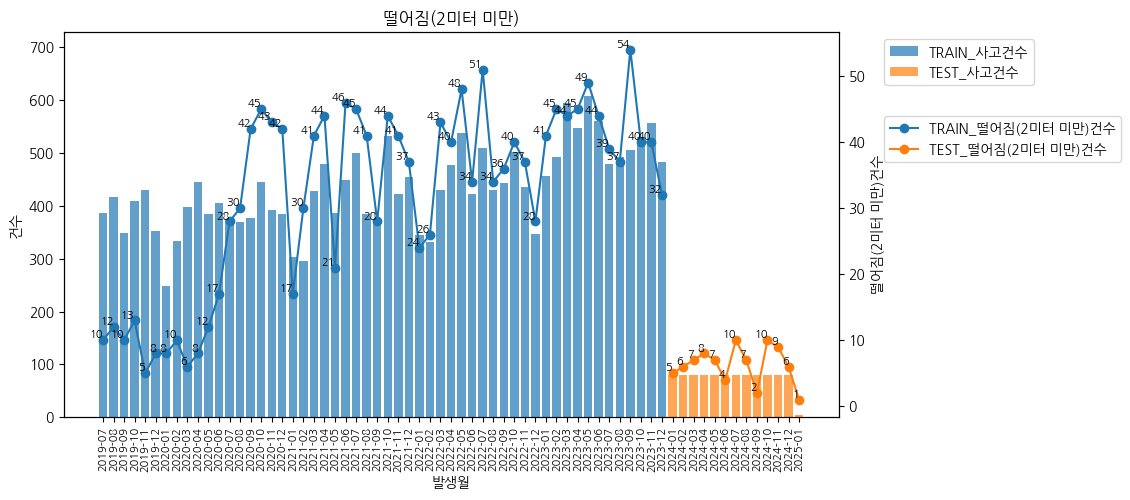

절단, 베임


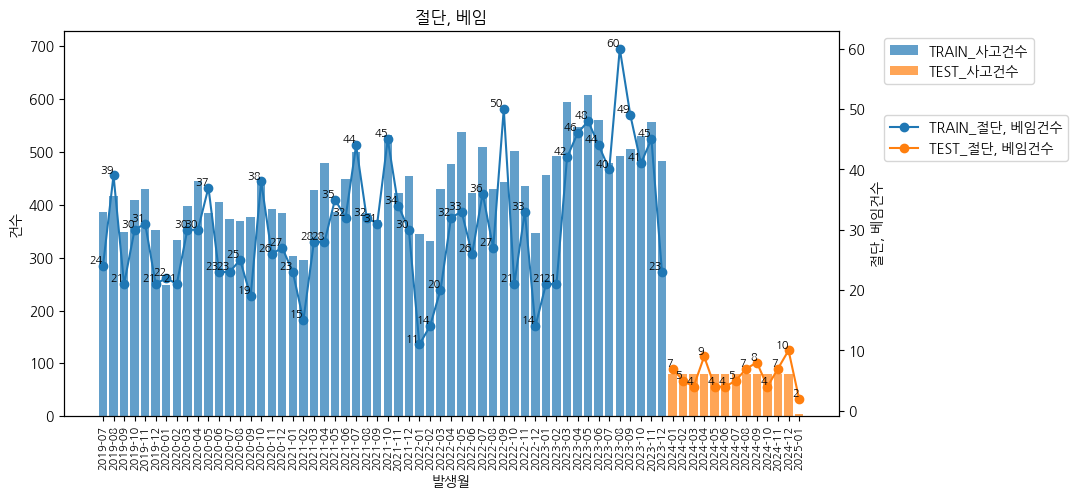

넘어짐(물체에 걸림)


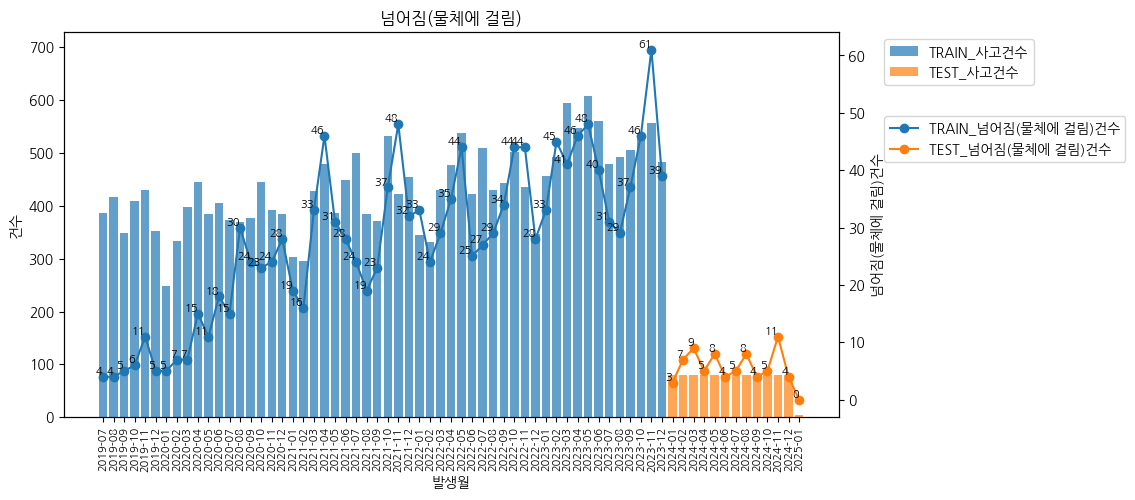

떨어짐(2미터 이상 ~ 3미터 미만)


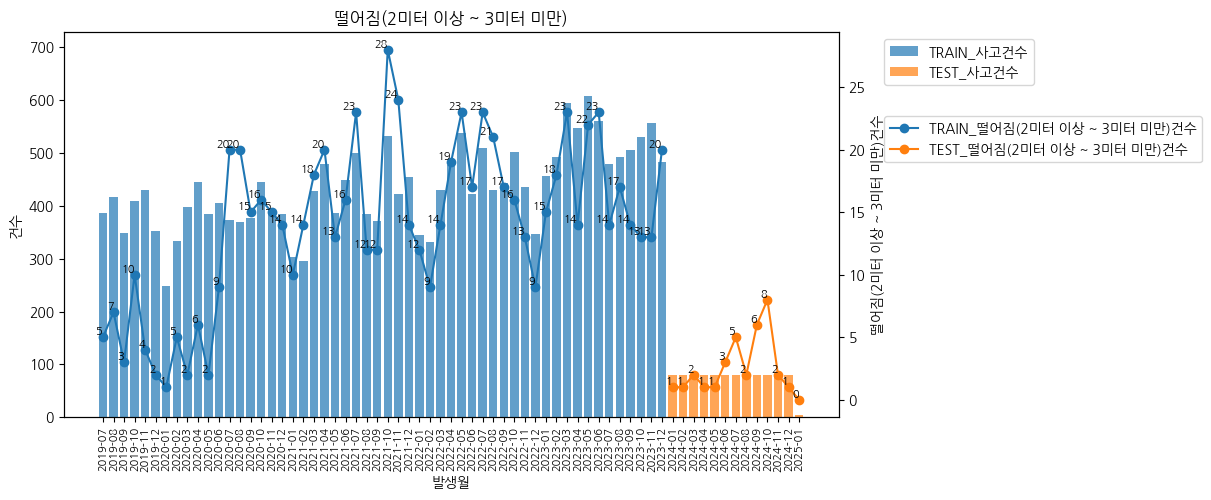

떨어짐(분류불능)


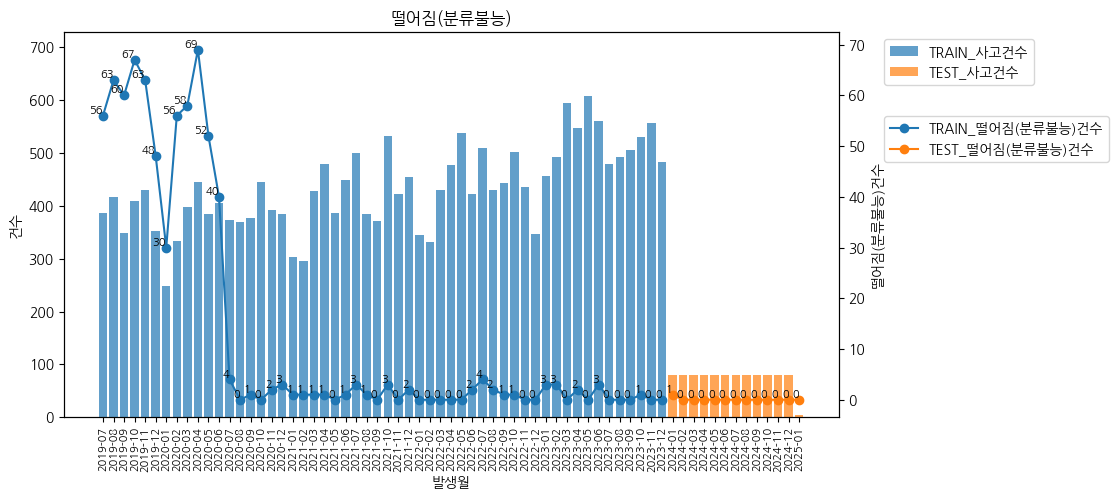

떨어짐(3미터 이상 ~ 5미터 미만)


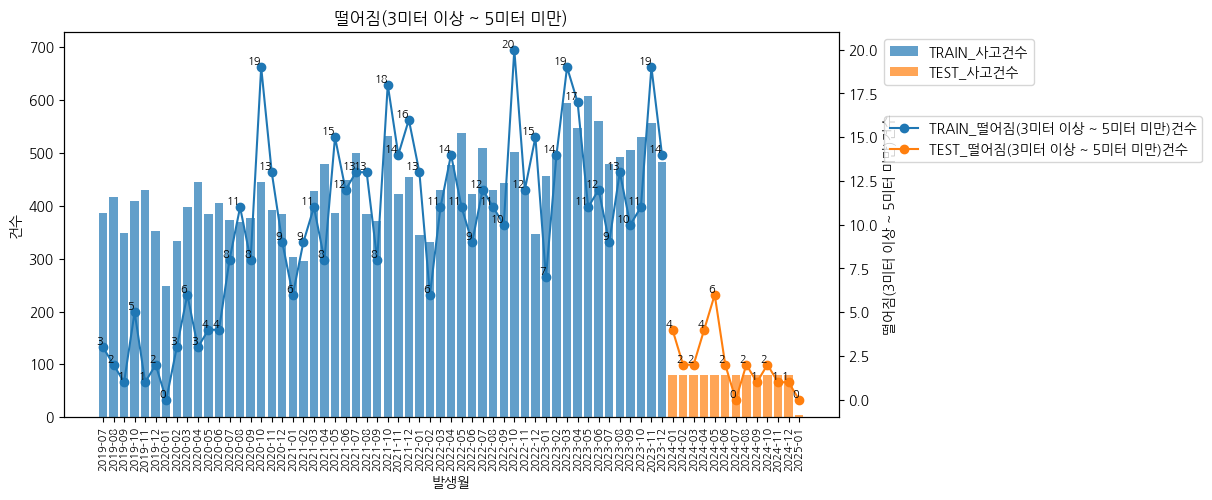

깔림


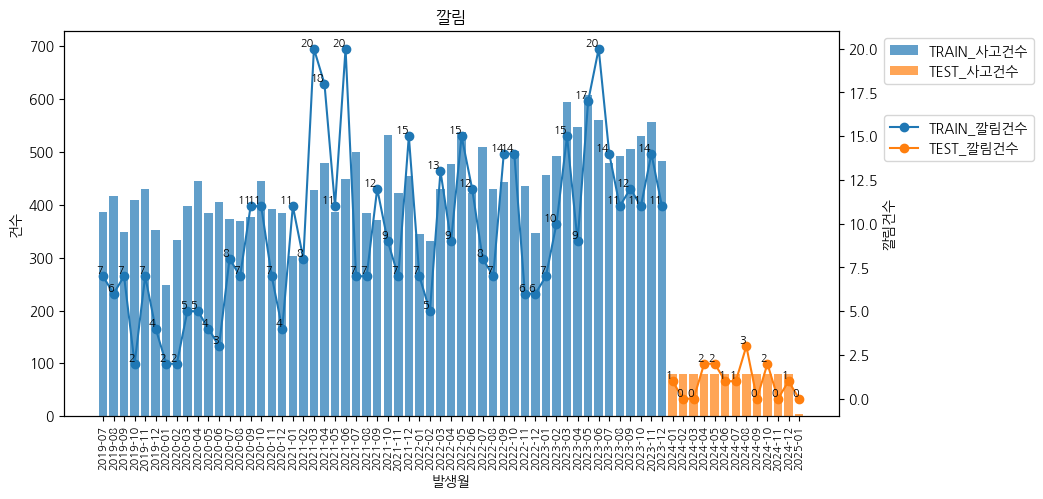

질병


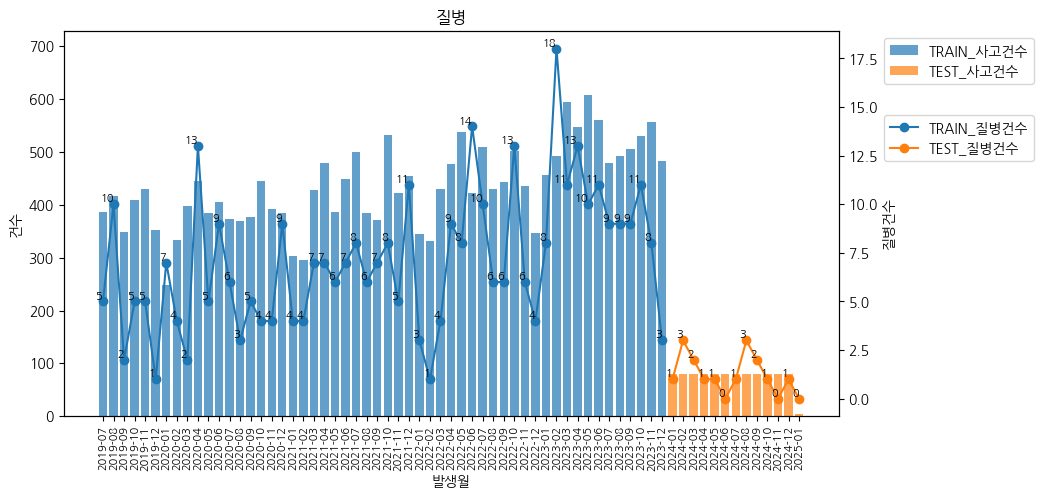

찔림


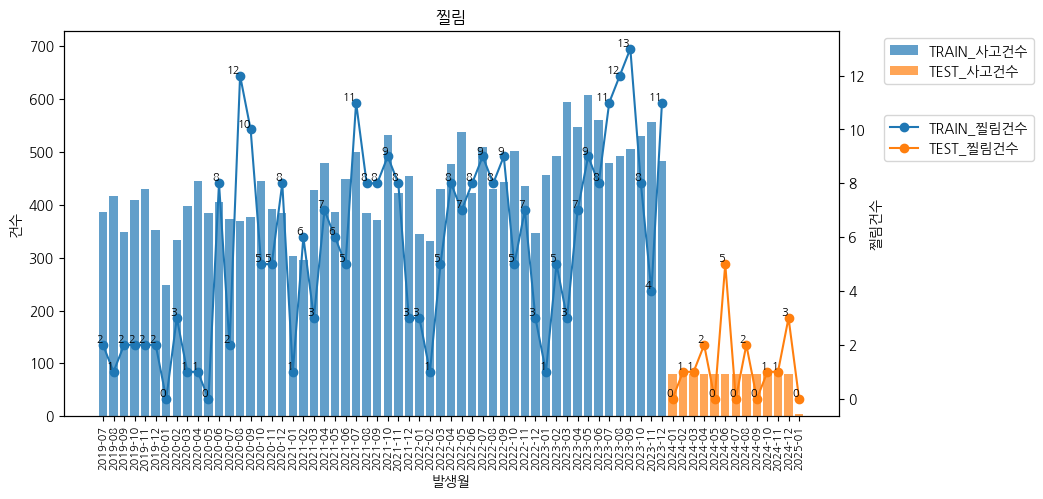

떨어짐(5미터 이상 ~ 10미터 미만)


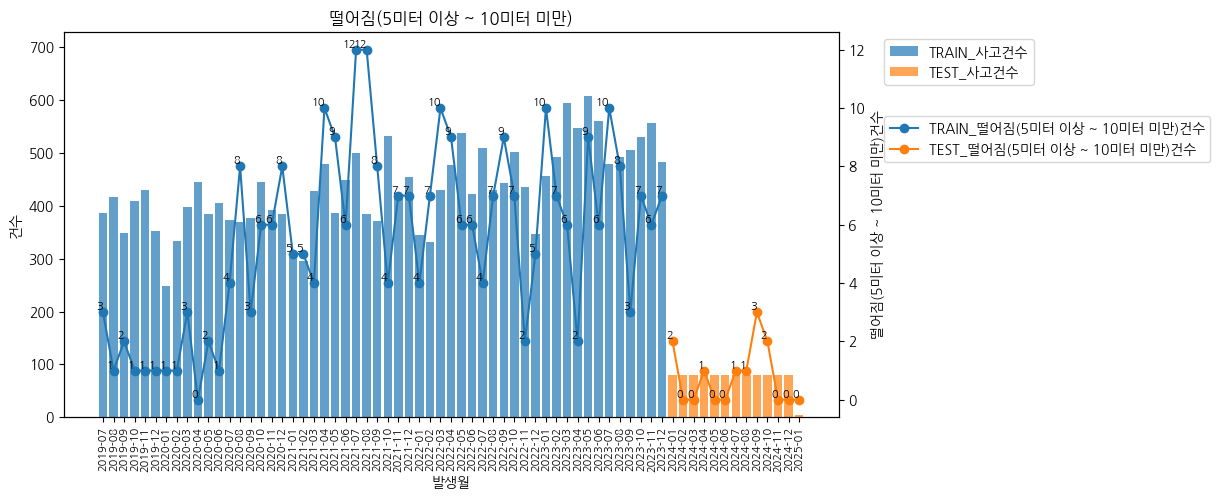

분류불능


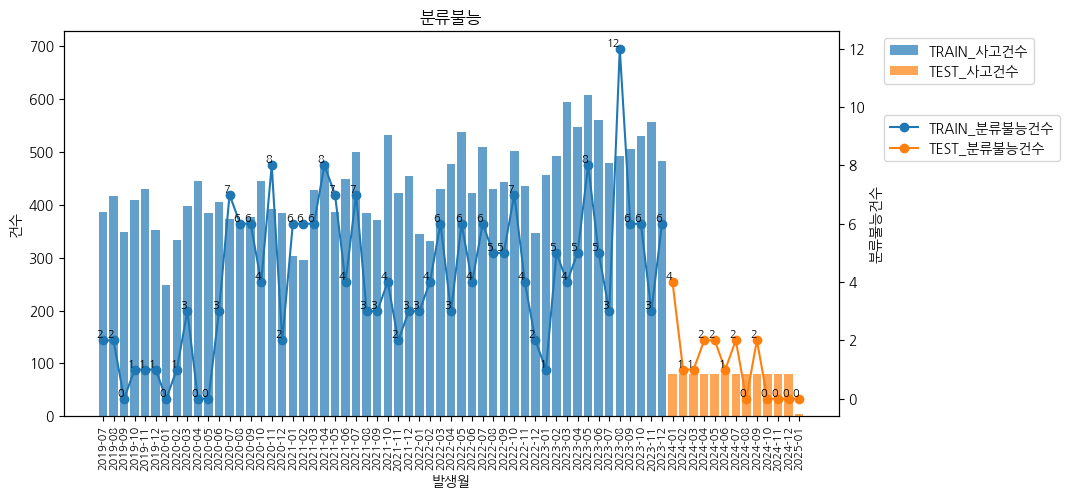

떨어짐(10미터 이상)


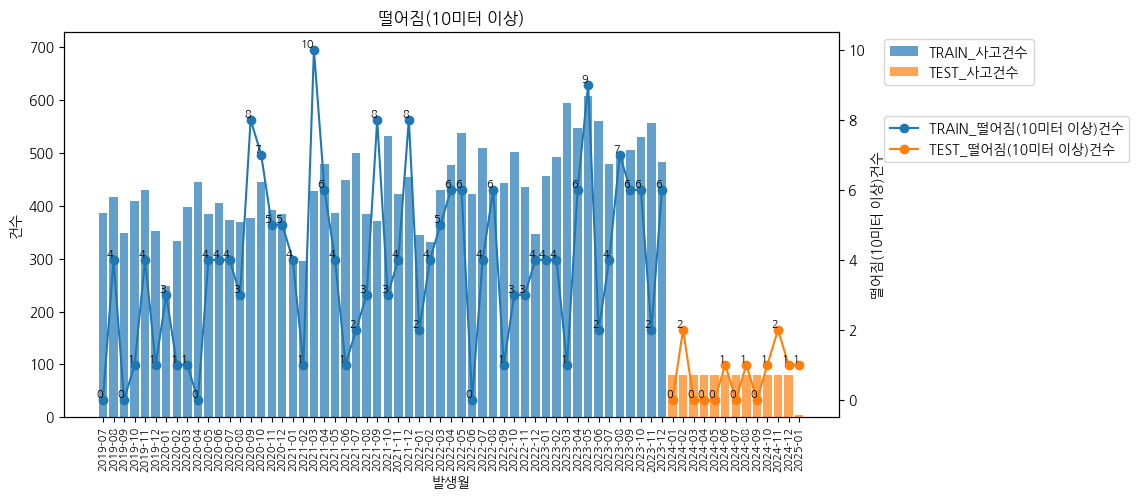

없음


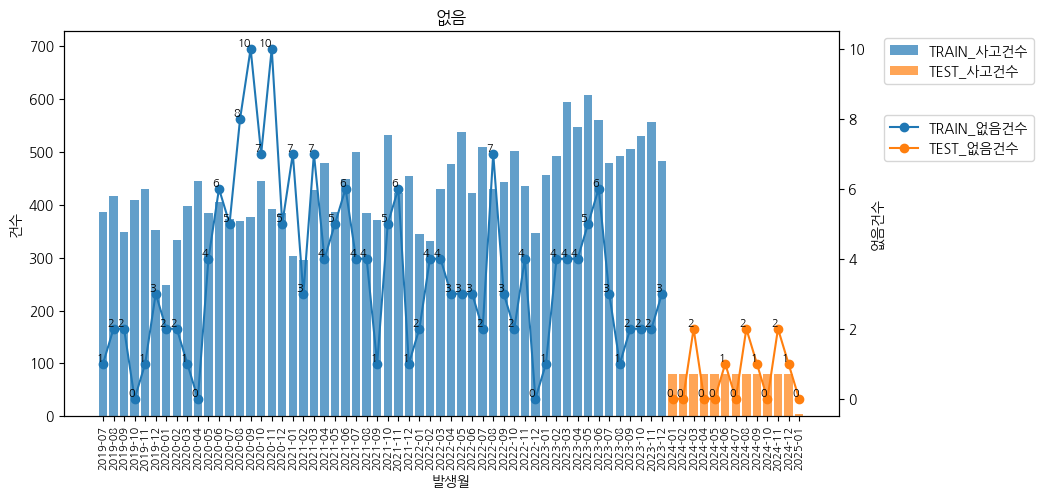

화상


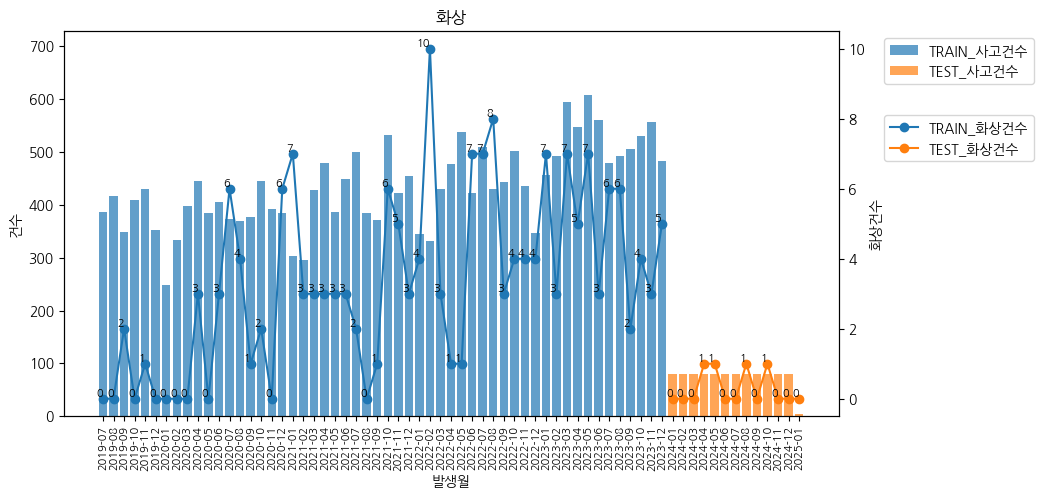

교통사고


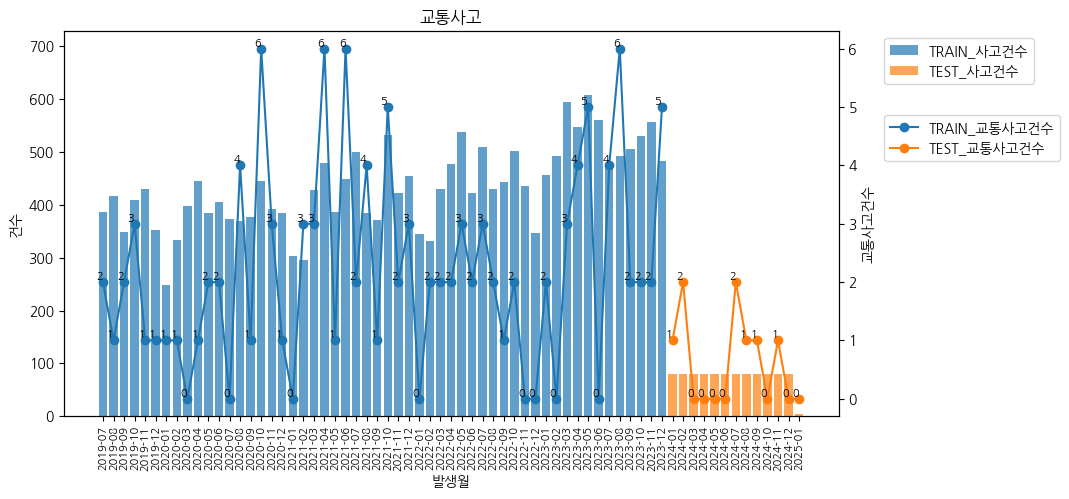

감전


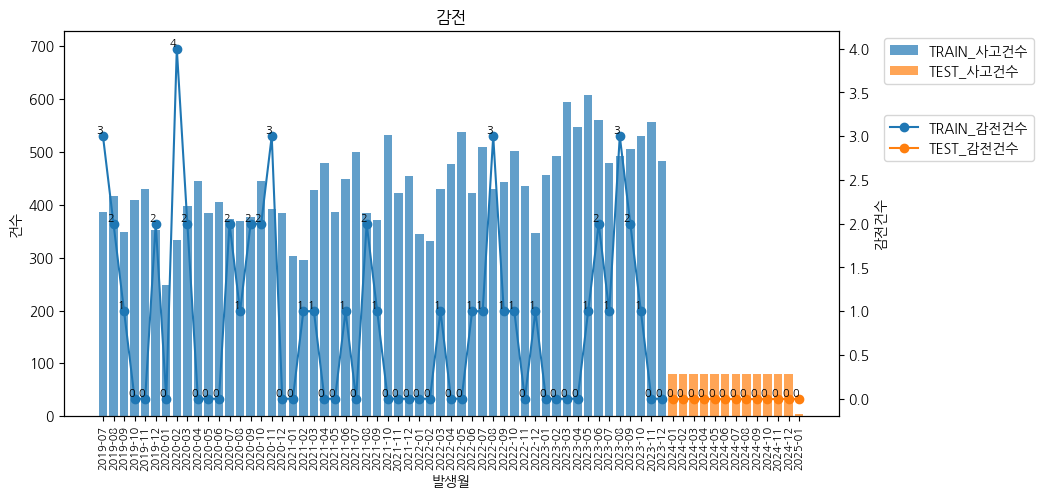

질식


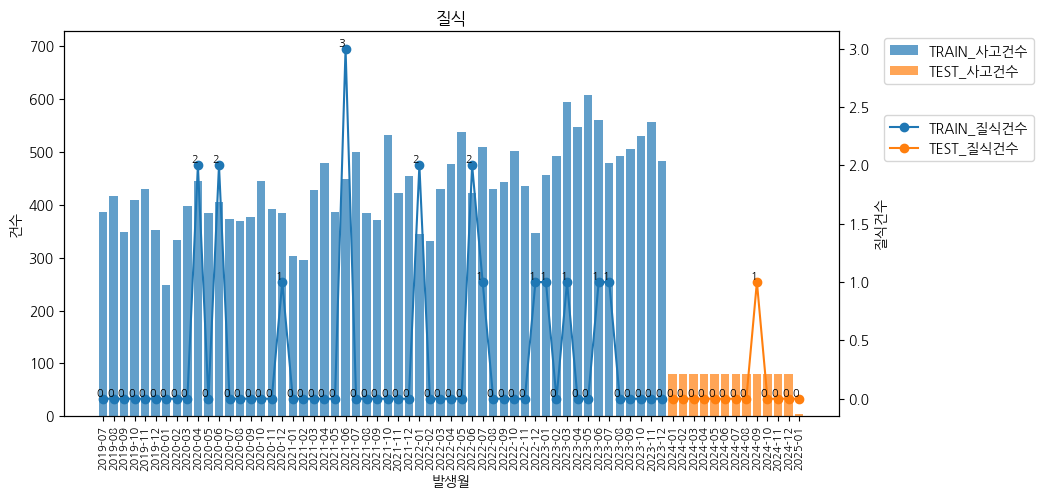

In [123]:
"""
(인적+물적)사고 시계열분석 
"""

for i in data['인적사고'].value_counts().index:
    print(i)
    make_plot1(사고유형=i)

📌 특징

#### train 
- 끼임 점점증가 
- 넘너짐(미끄러짐) 점점 급하게 증가 
- 넘어짐(기타)--> 2019년에는 많았다가 그 이후 줄어둠 
=> 넘어짐(미끄러짐), 넘어짐(기타)는 반비례 패턴을 보임
서로 분리해서 봐야 될듯.. 
- 기타 2019년에 많았다가 그 이후 줄어둠 
- 부딪힘 점점 증가 추세 
- 떨어짐(2미터 미만) 점점 증가 추세 

#### test 
- 떨어짐(분류불능) 없음
- 감전 없음 
- 질식 1건 발생 

## (✔️) train, test 카테고리 유형 비교

장소


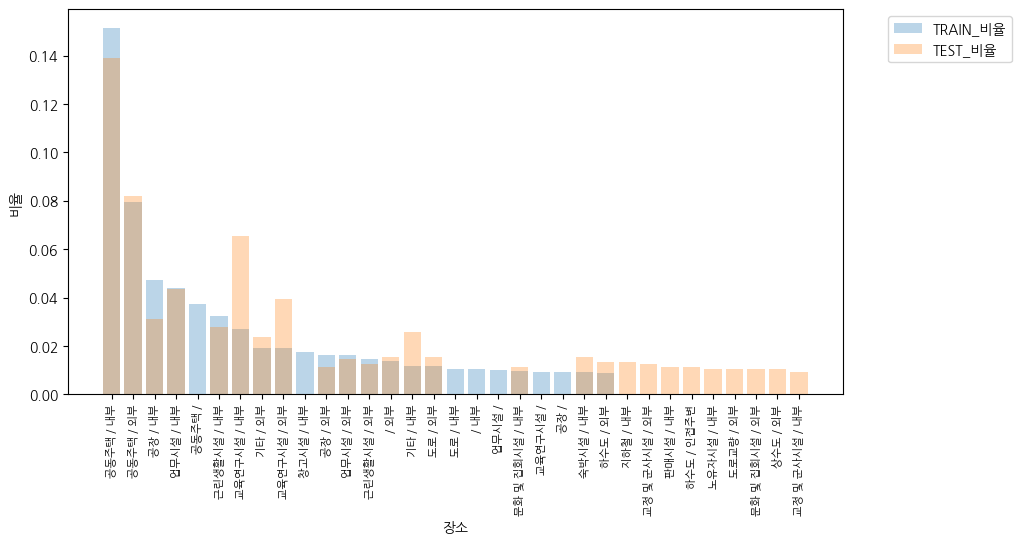

부위


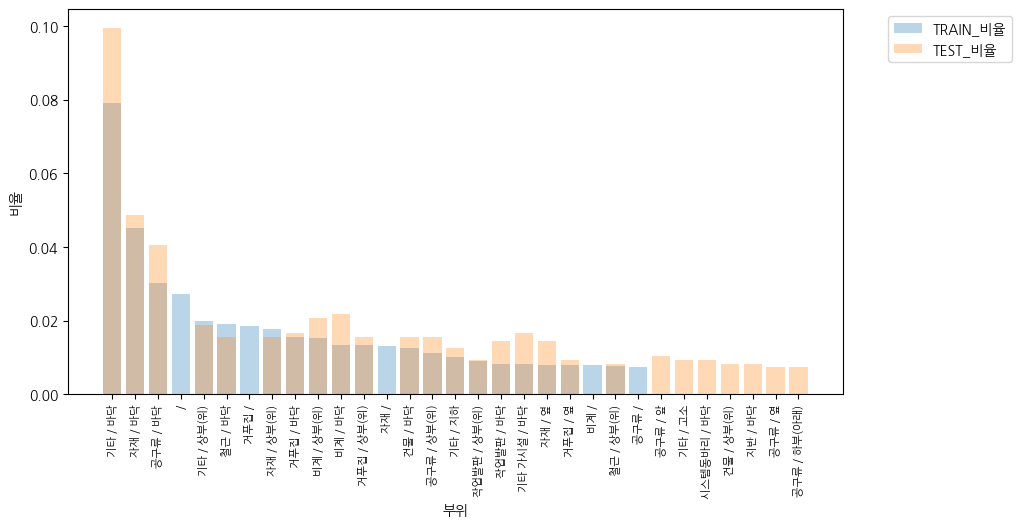

공종


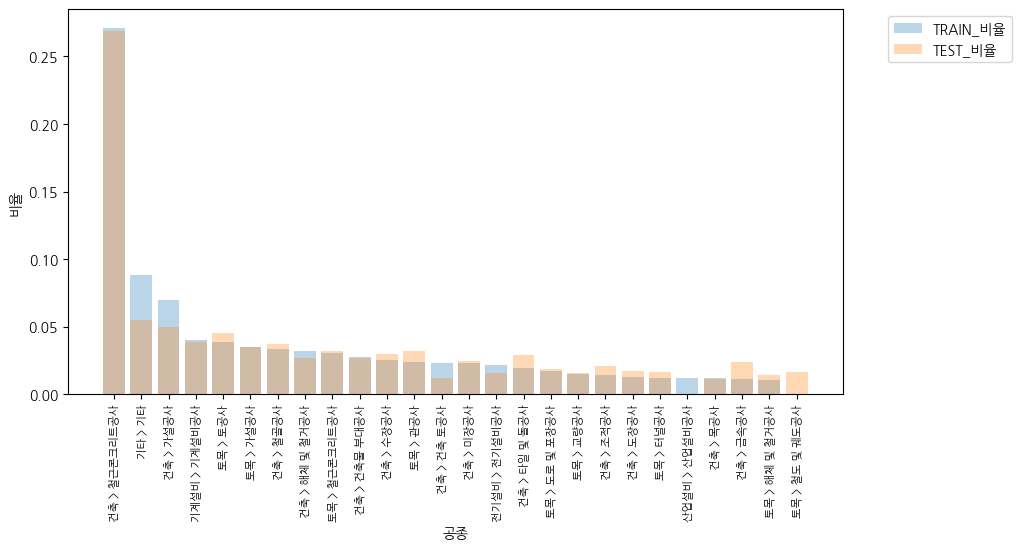

사고객체


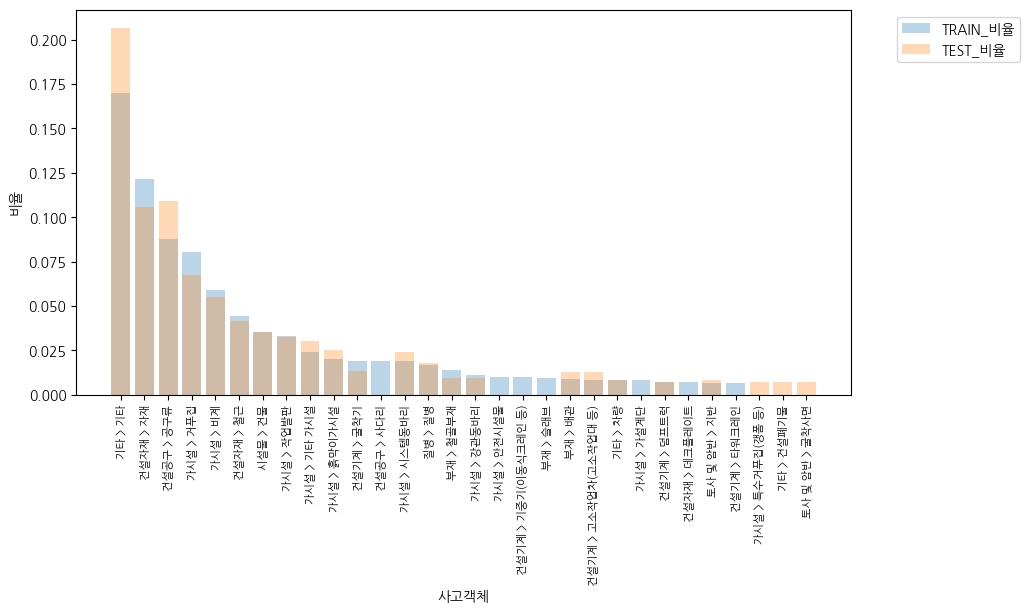

In [188]:
def make_plot2(feat,maxn=50):

    a1 = data.groupby(['데이터유형'])[feat].value_counts(normalize=True).nlargest(maxn).reset_index(name='비율') # plot.bar()
    
    # 그래프 생성
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # 막대 그래프 (a1: 전체 사고 건수)
    for category, group in sorted(a1.groupby('데이터유형'), reverse=True):
        ax1.bar(group[feat], group['비율'], label=f"{category}비율", alpha=0.3)
    
    ax1.set_xlabel(feat)
    ax1.set_ylabel("비율")
    
    # X축 포맷 및 글꼴 크기 조정
    plt.xticks(rotation=90, size=8);
    
    ax1.legend(loc="upper left", bbox_to_anchor=(1.05, 1))
    
    plt.show()


feats = [
 #'공사종류(대분류)',
 #'공사종류(중분류)',
 #'공종(대분류)',
 #'공종(중분류)',
 #'사고객체(대분류)',
 #'사고객체(중분류)', 
 #'작업프로세스'
 '장소',
 '부위',
 '공종', 
 '사고객체'
]

for feat in feats:
    print(feat)
    make_plot2(feat=feat)

> 데이터 생성 

In [ ]:
# 훈련 데이터 통합 생성
combined_training_data = train.apply(
    lambda row: {
        "question": (
            f"공사종류 대분류 '{row['공사종류(대분류)']}', 중분류 '{row['공사종류(중분류)']}' 공사 중 "
            f"공종 대분류 '{row['공종(대분류)']}', 중분류 '{row['공종(중분류)']}' 작업에서 "
            f"사고객체 '{row['사고객체(대분류)']}'(중분류: '{row['사고객체(중분류)']}')와 관련된 사고가 발생했습니다. "
            f"작업 프로세스는 '{row['작업프로세스']}'이며, 사고 원인은 '{row['사고원인']}'입니다. "
            f"재발 방지 대책 및 향후 조치 계획은 무엇인가요?"
        ),
        "answer": row["재발방지대책 및 향후조치계획"]
    },
    axis=1
)

# DataFrame으로 변환
combined_training_data = pd.DataFrame(list(combined_training_data))

In [ ]:
# 테스트 데이터 통합 생성
combined_test_data = test.apply(
    lambda row: {
        "question": (
            f"공사종류 대분류 '{row['공사종류(대분류)']}', 중분류 '{row['공사종류(중분류)']}' 공사 중 "
            f"공종 대분류 '{row['공종(대분류)']}', 중분류 '{row['공종(중분류)']}' 작업에서 "
            f"사고객체 '{row['사고객체(대분류)']}'(중분류: '{row['사고객체(중분류)']}')와 관련된 사고가 발생했습니다. "
            f"작업 프로세스는 '{row['작업프로세스']}'이며, 사고 원인은 '{row['사고원인']}'입니다. "
            f"재발 방지 대책 및 향후 조치 계획은 무엇인가요?"
        )
    },
    axis=1
)

# DataFrame으로 변환
combined_test_data = pd.DataFrame(list(combined_test_data))